# Week 5 (Day 18) — Notebook 01
## Preprocessing for Clustering (Scaling + Mixed Data Pipelines)

This notebook is hands-on:
- Load the Nigerian customer segmentation dataset
- Compare clustering **with vs without scaling**
- Handle **mixed numeric + categorical** features using `ColumnTransformer`
- Visualize clusters in 2D (PCA) and compare internal metrics

Dataset: `nigerian_customer_segments.csv`

> Note: `segment_hint` exists only for instructor sanity checks — do not use it to train clustering models.

In [2]:
# Setup: imports, settings, helper utilities
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def _safe_internal_metrics(X, labels):
    """Compute internal clustering metrics when valid.

    Returns dict with keys: silhouette, Davies–Bouldin, Calinski–Harabasz.
    Uses NaN when a metric is undefined.
    """
    metrics = {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}

    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return metrics
    if len(unique_labels) == len(labels):
        # Each point its own cluster (silhouette undefined)
        return metrics

    try:
        metrics["silhouette"] = float(silhouette_score(X, labels))
    except Exception:
        pass

    try:
        metrics["davies_bouldin"] = float(davies_bouldin_score(X, labels))
    except Exception:
        pass

    try:
        metrics["calinski_harabasz"] = float(calinski_harabasz_score(X, labels))
    except Exception:
        pass

    return metrics


def pca_2d_plot(X, labels, title, ax=None):
    """Project X to 2D using PCA and plot colored by labels."""
    if ax is None:
        fig, ax = plt.subplots()
        _ = fig

    X_dense = X.toarray() if hasattr(X, "toarray") else X
    X_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_dense)

    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=20, alpha=0.85, label=str(lab))

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")


def run_kmeans(X, k=4, n_init=10):
    """Fit KMeans and return labels + runtime + inertia + internal metrics."""
    start = time.time()
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=n_init)
    labels = model.fit_predict(X)
    runtime_s = time.time() - start

    inertia = float(getattr(model, "inertia_", np.nan))
    metrics = _safe_internal_metrics(X, labels)

    return {
        "labels": labels,
        "runtime_s": runtime_s,
        "inertia": inertia,
        **metrics,
    }


print("Setup complete.")

Setup complete.


## Load dataset
We’ll use a mixed-type dataset (numeric + categorical):
- Numeric: income, spend, purchases, visits, tenure, late payments
- Categorical: state, gender, employment type, preferred channel, etc.

`segment_hint` is included for teaching sanity checks only (not used in clustering).

In [3]:
# Load dataset
from pathlib import Path

data_path = Path("nigerian_customer_segments.csv")
if not data_path.exists():
    # If running from workspace root, adjust relative path
    data_path = Path("Materials") / "Week 5" / "nigerian_customer_segments.csv"

df = pd.read_csv(data_path)
print("Loaded:", data_path)
print(df.shape)

df.head()

Loaded: nigerian_customer_segments.csv
(40, 15)


,customer_id,state,age,gender,employment_type,monthly_income_ngn,avg_monthly_spend_ngn,online_purchases_last_30d,store_visits_last_30d,tenure_months,smartphone,preferred_channel,has_bank_account,late_payments_last_12m,segment_hint
0,CUST0001,Lagos,28,F,private,420000,180000,12,2,18,yes,online,yes,0,digital_affluent
1,CUST0002,Lagos,34,M,private,520000,240000,15,1,26,yes,online,yes,1,digital_affluent
2,CUST0003,Abuja,31,F,private,380000,160000,10,3,20,yes,online,yes,0,digital_affluent
3,CUST0004,Rivers,29,M,private,450000,190000,11,2,15,yes,online,yes,0,digital_affluent
4,CUST0005,Oyo,36,F,private,600000,260000,16,2,32,yes,online,yes,0,digital_affluent


## Quick feature audit (why scaling matters)
Euclidean distance used by K-Means:

$$d(x,y)=\sqrt{\sum_i (x_i-y_i)^2}$$

If one column is on a much bigger numeric scale, it dominates the distance.

In [4]:
# Identify columns
id_col = "customer_id"
hint_col = "segment_hint"

feature_df = df.drop(columns=[c for c in [id_col, hint_col] if c in df.columns])

numeric_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in feature_df.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

feature_df[numeric_cols].describe().T[["min", "max", "mean", "std"]].sort_values("max", ascending=False)

Numeric columns: ['age', 'monthly_income_ngn', 'avg_monthly_spend_ngn', 'online_purchases_last_30d', 'store_visits_last_30d', 'tenure_months', 'late_payments_last_12m']
Categorical columns: ['state', 'gender', 'employment_type', 'smartphone', 'preferred_channel', 'has_bank_account']


,min,max,mean,std
monthly_income_ngn,50000.0,750000.0,279750.000,197178.657762
avg_monthly_spend_ngn,28000.0,420000.0,135575.000,101636.579197
tenure_months,4.0,130.0,39.775,36.133291
age,22.0,54.0,35.375,8.393183
online_purchases_last_30d,0.0,18.0,5.300,5.575588
store_visits_last_30d,1.0,13.0,4.875,3.283115
late_payments_last_12m,0.0,6.0,1.775,1.846514


## Baseline: K-Means on raw numeric features (no scaling)
This often produces misleading clusters when numeric ranges differ.

In [22]:
X_num_raw = feature_df[numeric_cols].copy()

# Simple imputation for any missing values (keeps demo robust)
# X_num_raw = X_num_raw.fillna(X_num_raw.median(numeric_only=True))

baseline = run_kmeans(X_num_raw, k=4)

pd.DataFrame([
    {
        "setup": "numeric_raw",
        "k": 4,
        **{k: baseline[k] for k in ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "runtime_s"]},
    }
])

,setup,k,inertia,silhouette,davies_bouldin,calinski_harabasz,runtime_s
0,numeric_raw,4,1.184563e+11,0.641566,0.466872,182.417837,0.022684


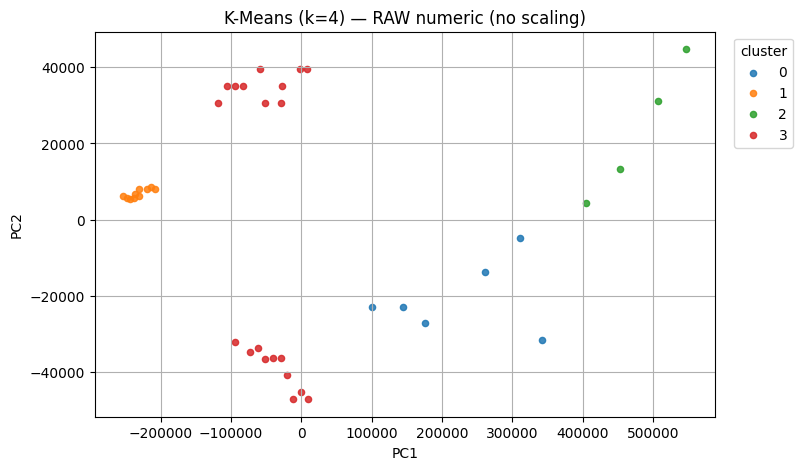

In [23]:
fig, ax = plt.subplots()
pca_2d_plot(X_num_raw, baseline["labels"], title="K-Means (k=4) — RAW numeric (no scaling)", ax=ax)
plt.show()

## Scaling: Standard vs MinMax vs Robust
We’ll run the *same* K-Means setup but change only the scaler.

Goal: see how cluster structure and metrics change.

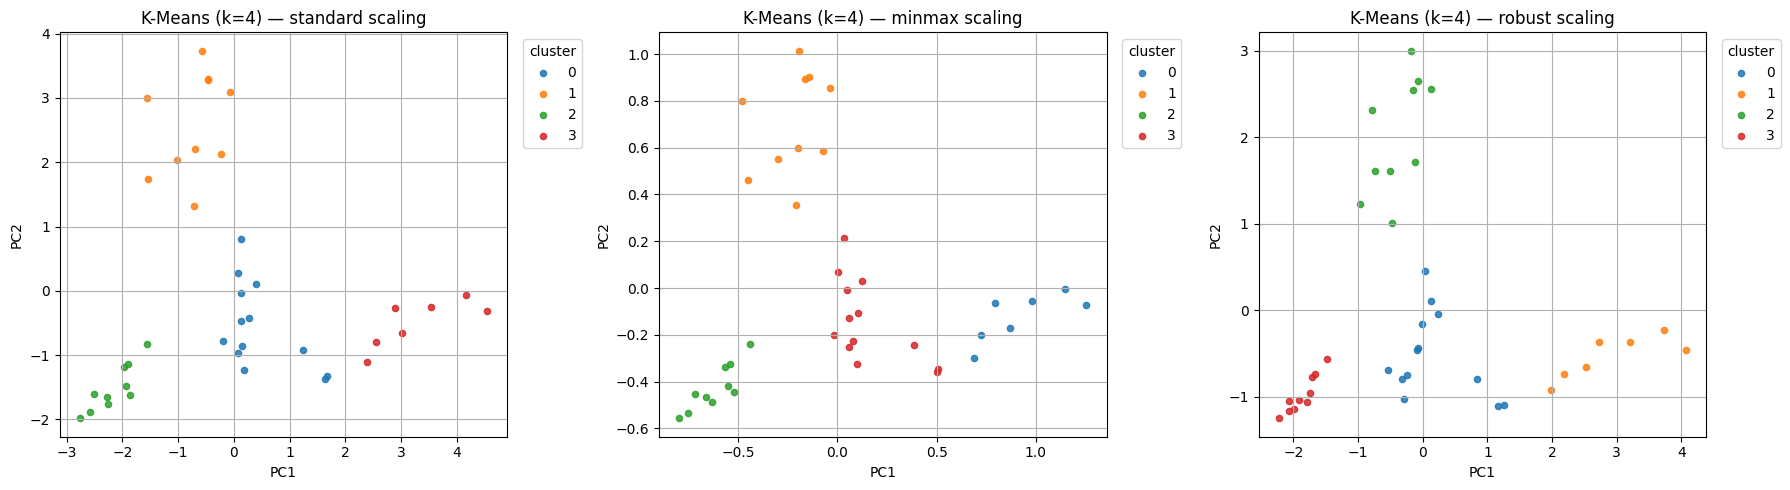

,setup,k,inertia,silhouette,davies_bouldin,calinski_harabasz,runtime_s
2,numeric_robust,4,24.918309,0.564354,0.584213,76.067190,0.007146
1,numeric_minmax,4,3.204359,0.555919,0.595185,70.243655,0.026118
0,numeric_standard,4,41.119125,0.552843,0.597697,69.713801,0.011037


In [7]:
scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

results = []
fig, axes = plt.subplots(1, len(scalers), figsize=(18, 5))

for ax, (name, scaler) in zip(axes, scalers.items()):
    X_scaled = scaler.fit_transform(X_num_raw)
    out = run_kmeans(X_scaled, k=4)

    results.append(
        {
            "setup": f"numeric_{name}",
            "k": 4,
            **{k: out[k] for k in ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "runtime_s"]},
        }
    )

    pca_2d_plot(X_scaled, out["labels"], title=f"K-Means (k=4) — {name} scaling", ax=ax)

plt.tight_layout()
plt.show()

pd.DataFrame(results).sort_values("silhouette", ascending=False)

## Mixed data pipeline (numeric + categorical)
Clustering needs numeric vectors. For mixed data:
- numeric: impute + scale
- categorical: impute + one-hot

Then K-Means runs on the combined feature matrix.

In [8]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)

X_mixed = preprocess.fit_transform(feature_df)
print("Transformed matrix shape:", X_mixed.shape)
print("Sparse output:", hasattr(X_mixed, "toarray"))

Transformed matrix shape: (40, 40)
Sparse output: False


In [25]:
mixed_out = run_kmeans(X_mixed, k=4)

summary = pd.DataFrame([
    {
        "setup": "mixed_standard+onehot",
        "k": 4,
        **{k: mixed_out[k] for k in ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "runtime_s"]},
    }
])
summary

,setup,k,inertia,silhouette,davies_bouldin,calinski_harabasz,runtime_s
0,mixed_standard+onehot,4,99.212992,0.468592,0.791713,39.960937,0.007866


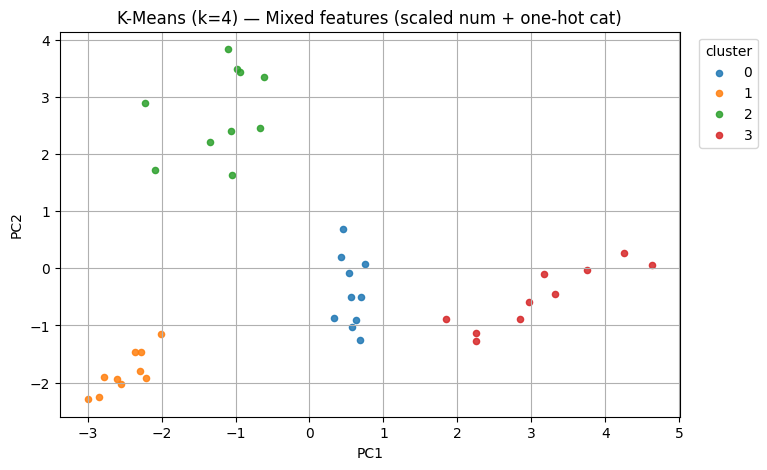

In [26]:
fig, ax = plt.subplots()
pca_2d_plot(X_mixed, mixed_out["labels"], title="K-Means (k=4) — Mixed features (scaled num + one-hot cat)", ax=ax)
plt.show()

## Results table (baseline vs scalers vs mixed)
We’ll consolidate the outputs into one table for easy comparison.

In [27]:
all_rows = []

# baseline (raw)
all_rows.append(
    {
        "setup": "numeric_raw",
        "k": 4,
        **{k: baseline[k] for k in ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "runtime_s"]},
    }
)

# scalers
all_rows.extend(results)

# mixed
all_rows.append(
    {
        "setup": "mixed_standard+onehot",
        "k": 4,
        **{k: mixed_out[k] for k in ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "runtime_s"]},
    }
)

comparison_df = pd.DataFrame(all_rows)
comparison_df.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])

,setup,k,inertia,silhouette,davies_bouldin,calinski_harabasz,runtime_s
0,numeric_raw,4,1.184563e+11,0.641566,0.466872,182.417837,0.022684
3,numeric_robust,4,2.491831e+01,0.564354,0.584213,76.067190,0.007146
2,numeric_minmax,4,3.204359e+00,0.555919,0.595185,70.243655,0.026118
1,numeric_standard,4,4.111912e+01,0.552843,0.597697,69.713801,0.011037
4,mixed_standard+onehot,4,9.921299e+01,0.468592,0.791713,39.960937,0.007866


## Practice (10 minutes)
1) Change `k` from 4 → 3 and 5. What changes?
2) Remove one numeric feature (e.g., `monthly_income_ngn`) and rerun.
3) Try `RobustScaler()` in the mixed pipeline instead of `StandardScaler()`.

Write down:
- which preprocessing choice changed clusters the most
- which cluster result is most interpretable

In [28]:
# TODO: Practice cell (edit freely)
# Example: swap StandardScaler -> RobustScaler in the mixed pipeline

numeric_pipe_robust = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

preprocess_robust = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_robust, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ]
)

X_mixed_robust = preprocess_robust.fit_transform(feature_df)
out_robust = run_kmeans(X_mixed_robust, k=4)

pd.DataFrame([
    {
        "setup": "mixed_robust+onehot",
        "k": 4,
        **{k: out_robust[k] for k in ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "runtime_s"]},
    }
])

,setup,k,inertia,silhouette,davies_bouldin,calinski_harabasz,runtime_s
0,mixed_robust+onehot,4,82.97853,0.462429,0.806512,36.080937,0.007413
